In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

In [3]:
X,y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

In [4]:
x_min, x_max = X[:,0].min() - 1, X[:,0].max()+1
y_min, y_max = X[:,0].min() - 1, X[:,0].max()+1 

In [5]:
xx,yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

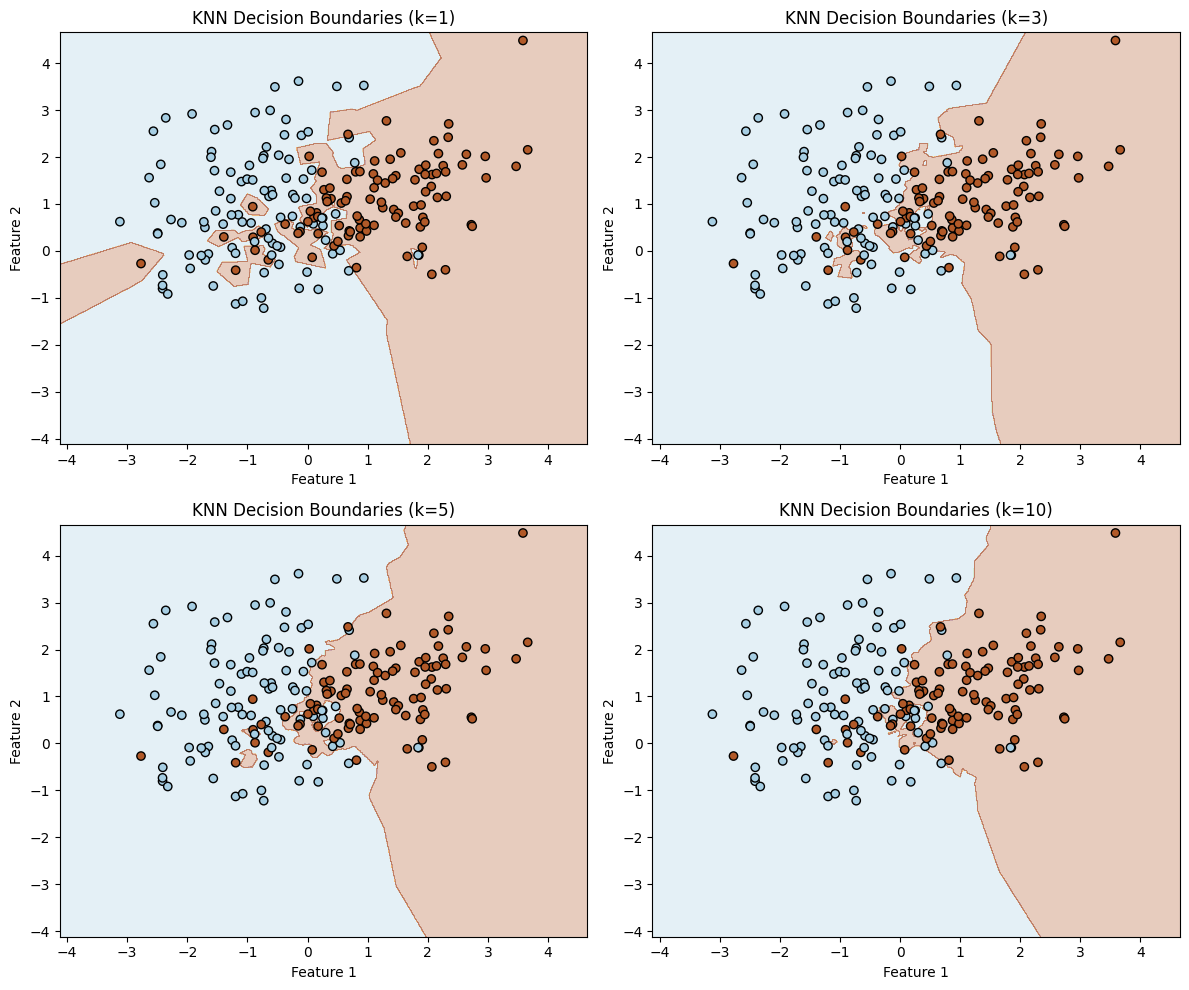

In [8]:
fig, axs = plt.subplots(2,2, figsize=(12,10))
k_values = [1,3,5,10]

for ax, k in zip(axs.flat, k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X,y)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k',
               cmap=plt.cm.Paired, marker='o')
    ax.set_title(f'KNN Decision Boundaries (k={k})')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig("figure/decision_boundry")
plt.show()